## Импорты

In [1]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.interpolate import interp1d
from scipy.fft import fft, ifft, fftfreq

# Настройка графиков
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-darkgrid')

## Задание 1

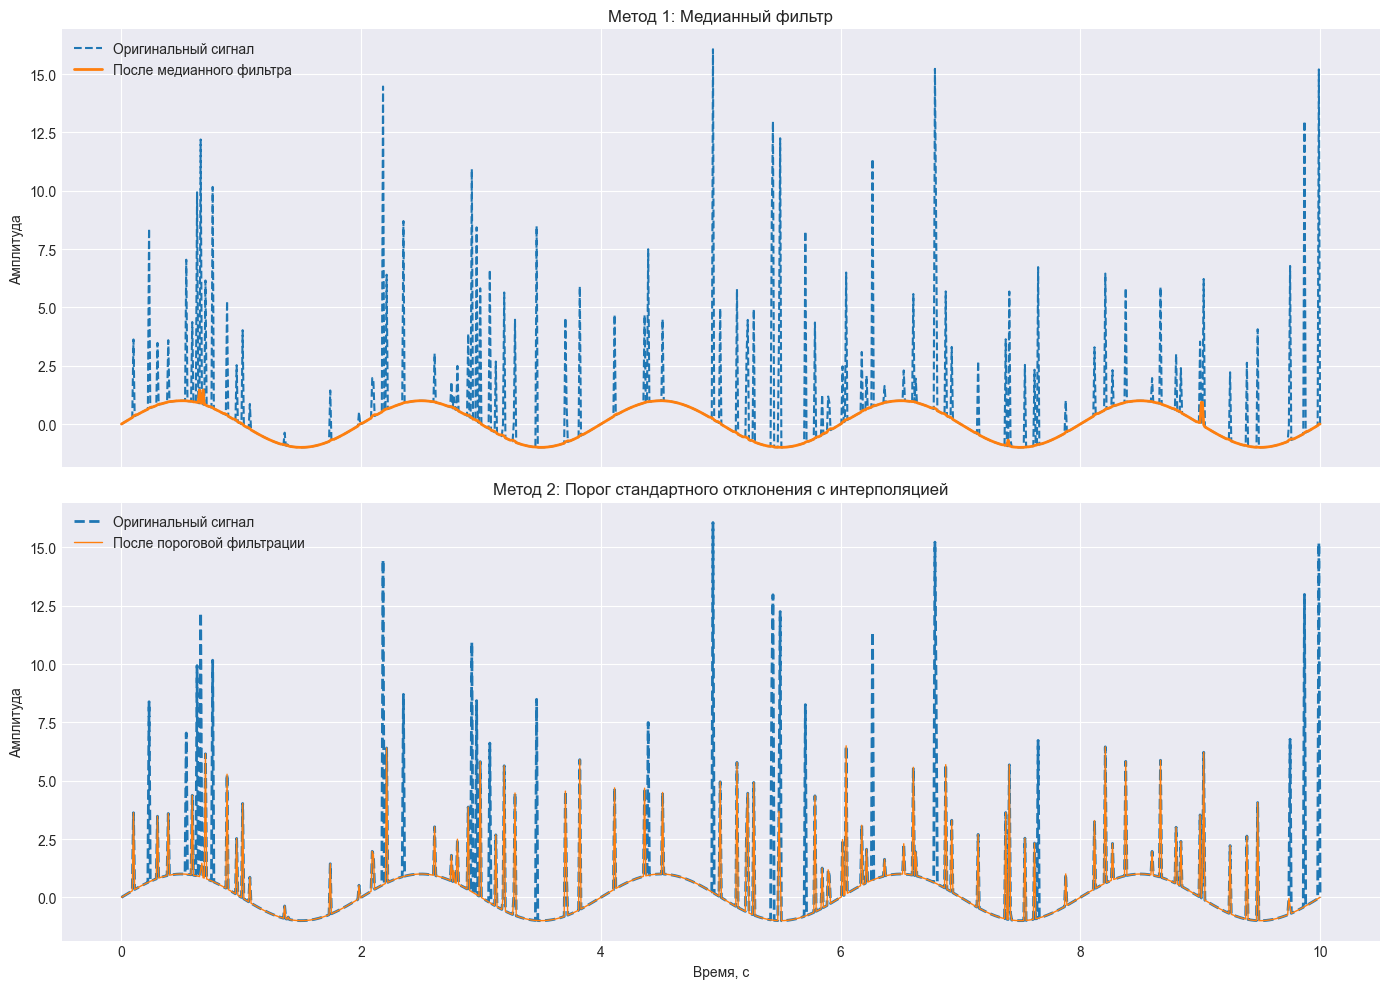

In [ ]:
np.random.seed(42)
t = np.linspace(0, 10, 1000)
clean_signal = np.sin(2 * np.pi * 0.5 * t)  


num_spikes = 100 
spike_indices = np.random.choice(len(t), size=num_spikes, replace=False)
spike_amplitude = np.abs(6 * np.random.randn(num_spikes))  
noisy_signal = clean_signal.copy()
noisy_signal[spike_indices] += spike_amplitude


def median_filter_removal(sig, kernel_size=5):
    return signal.medfilt(sig, kernel_size=kernel_size)

filtered_median = median_filter_removal(noisy_signal, kernel_size=5)


def std_threshold_removal(sig, threshold_factor=3.0):
   
    mean_val = np.mean(sig)
    std_val = np.std(sig)
    lower_bound = mean_val - threshold_factor * std_val
    upper_bound = mean_val + threshold_factor * std_val
    
    
    outlier_mask = (sig < lower_bound) | (sig > upper_bound)
    
   
    sig_cleaned = sig.astype(float)
    sig_cleaned[outlier_mask] = np.nan

    nans = np.isnan(sig_cleaned)
    if np.any(nans):
        x = np.arange(len(sig_cleaned))
        sig_cleaned[nans] = np.interp(x[nans], x[~nans], sig_cleaned[~nans])
    
    return sig_cleaned, outlier_mask

filtered_std, outlier_mask = std_threshold_removal(noisy_signal, threshold_factor=3.0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)


axes[0].plot(t, noisy_signal, '--', linewidth=1.5, label='Оригинальный сигнал')
axes[0].plot(t, filtered_median, linewidth=2, label='После медианного фильтра')
axes[0].set_ylabel('Амплитуда')
axes[0].set_title('Метод 1: Медианный фильтр')
axes[0].legend()
axes[0].grid(True)


axes[1].plot(t, noisy_signal, '--', linewidth=2, label='Оригинальный сигнал')
axes[1].plot(t, filtered_std, linewidth=1, label='После пороговой фильтрации')

# axes[1].scatter(t[outlier_mask], noisy_signal[outlier_mask], 
#                 color='red', s=30, alpha=0.7, label='Обнаруженные выбросы')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Амплитуда')
axes[1].set_title('Метод 2: Порог стандартного отклонения с интерполяцией')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Метод порога стандартного отклонения вычисляет глобальное среднее и стандартное отклонение зашумлённого сигнала. Все точки, выходящие за пределы mean ± 3σ, считаются выбросами и заменяются на NaN. Затем пропуски заполняются линейной интерполяцией по соседним корректным значениям.

## Задание 2

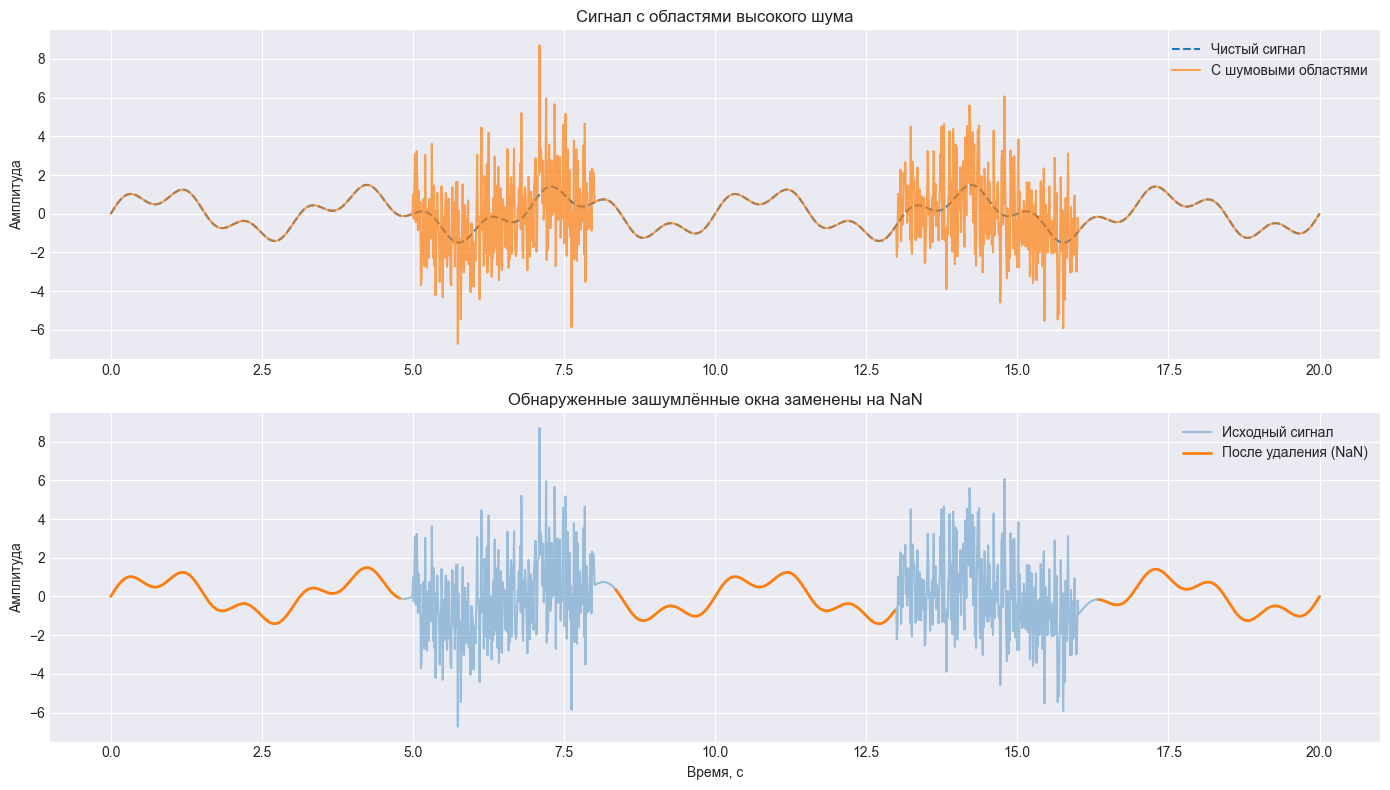

In [53]:
# Задание 2. Удаление зашумлённых областей с помощью скользящего RMS

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation

# Генерация сигнала с зашумлёнными областями
np.random.seed(42)
t = np.linspace(0, 20, 2000)
base_signal = np.sin(2 * np.pi * 0.3 * t) + 0.5 * np.sin(2 * np.pi * 1.0 * t)

# Интервалы с высоким шумом
noise_mask = np.zeros_like(t, dtype=bool)
noise_mask[(t > 5) & (t < 8)] = True
noise_mask[(t > 13) & (t < 16)] = True

noise_signal = base_signal.copy()
noise_signal[noise_mask] += np.random.normal(0, 2.0, size=np.sum(noise_mask))

# Метод скользящего RMS с адаптивным порогом
def sliding_rms_removal(sig, window_size, threshold_multiplier=3.0, dilation_size=50):
    """
    Обнаружение зашумленных участков по скользящему RMS.
    Порог = median(RMS) * threshold_multiplier.
    """
    half = window_size // 2
    rms = np.zeros_like(sig)
    for i in range(len(sig)):
        start = max(0, i - half)
        end = min(len(sig), i + half + 1)
        rms[i] = np.sqrt(np.mean(sig[start:end]**2))
    
    # Используем медиану RMS как оценку базового уровня (без шума)
    baseline_rms = np.median(rms)
    threshold = baseline_rms * threshold_multiplier
    
    # Первичная маска по порогу
    bad_mask = rms > threshold
    
    # Расширение маски, чтобы захватить переходные зоны
    if dilation_size > 0:
        bad_mask = binary_dilation(bad_mask, structure=np.ones(dilation_size))
    
    return bad_mask

# Параметры (можно подстроить)
window = 100            # ширина окна в отсчётах
threshold_multiplier = 2.0   # коэффициент превышения медианы
dilation = 100           # расширение маски

bad_mask = sliding_rms_removal(noise_signal, window, threshold_multiplier, dilation)

cleaned_signal = noise_signal.copy()
cleaned_signal[bad_mask] = np.nan

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(t, base_signal, '--', label='Чистый сигнал')
axes[0].plot(t, noise_signal, alpha=0.7, label='С шумовыми областями')
axes[0].set_ylabel('Амплитуда')
axes[0].set_title('Сигнал с областями высокого шума')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, noise_signal, alpha=0.4, label='Исходный сигнал')
axes[1].plot(t, cleaned_signal, linewidth=2, label='После удаления (NaN)')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Амплитуда')
axes[1].set_title('Обнаруженные зашумлённые окна заменены на NaN')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Задание 3

Использован размер окна: 250 отсчётов


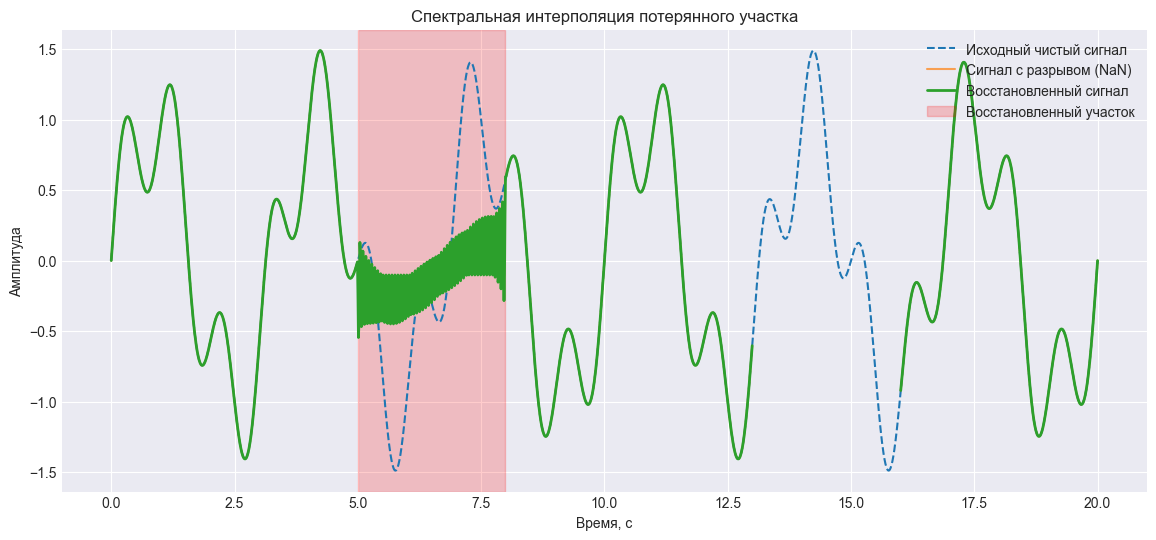

In [54]:
# Задание 3. Спектральная интерполяция с автоматическим выбором чистых окон

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

def spectral_interpolation_safe(signal_with_nan, gap_start_idx, gap_end_idx, max_window_size):
    """
    Восстановление пропущенного участка с автоматическим обрезанием окон до чистых данных.
    """
    # Находим границы разрыва (первый и последний индекс NaN в указанном диапазоне)
    nan_mask = np.isnan(signal_with_nan)
    
    # Определяем левый чистый участок (двигаемся влево от gap_start_idx-1, пока не встретим NaN)
    left_end = gap_start_idx - 1
    left_start = left_end
    while left_start >= 0 and not nan_mask[left_start]:
        left_start -= 1
    left_start += 1  # возвращаемся к первому чистому отсчёту
    
    # Аналогично правый чистый участок
    right_start = gap_end_idx + 1
    right_end = right_start
    while right_end < len(signal_with_nan) and not nan_mask[right_end]:
        right_end += 1
    right_end -= 1
    
    # Определяем доступную длину окон (но не более max_window_size)
    left_avail = left_end - left_start + 1
    right_avail = right_end - right_start + 1
    win_size = min(max_window_size, left_avail, right_avail)
    
    if win_size < 10:
        raise ValueError("Недостаточно чистых отсчётов для спектральной интерполяции")
    
    # Берём окна равной длины
    left_window = signal_with_nan[left_end - win_size + 1 : left_end + 1]
    right_window = signal_with_nan[right_start : right_start + win_size]
    
    # Убеждаемся, что нет NaN
    assert not np.any(np.isnan(left_window)) and not np.any(np.isnan(right_window))
    
    # Спектры
    left_spec = fft(left_window)
    right_spec = fft(right_window)
    avg_spec = (left_spec + right_spec) / 2
    
    # Восстановление пропущенного участка
    gap_len = gap_end_idx - gap_start_idx + 1
    recon = np.real(ifft(avg_spec, n=gap_len))
    
    # Сшивка границ
    left_val = left_window[-1]
    right_val = right_window[0]
    x_line = np.linspace(0, 1, gap_len)
    trend = (1 - x_line) * left_val + x_line * right_val
    recon = recon - np.mean(recon) + np.mean(trend)
    recon = recon - recon[0] + left_val
    recon = recon - recon[-1] + right_val
    
    return recon, win_size

manual_gap_signal = base_signal.copy()
manual_gap_signal[noise_mask] = np.nan

# Выбираем разрыв (например, первый)
gap_start = np.where((t > 5) & (t < 5.1))[0][0]
gap_end = np.where((t > 7.9) & (t < 8))[0][-1]

max_win = 250  # максимальное желаемое окно
restored_gap, used_win = spectral_interpolation_safe(manual_gap_signal, gap_start, gap_end, max_win)

# Восстановленный сигнал
restored_signal = manual_gap_signal.copy()
restored_signal[gap_start:gap_end+1] = restored_gap

print(f"Использован размер окна: {used_win} отсчётов")

# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(t, base_signal, '--', linewidth=1.5, label='Исходный чистый сигнал')
plt.plot(t, manual_gap_signal, alpha=0.7, label='Сигнал с разрывом (NaN)')
plt.plot(t, restored_signal, linewidth=2, label='Восстановленный сигнал')
plt.axvspan(t[gap_start], t[gap_end], alpha=0.2, color='red', label='Восстановленный участок')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Спектральная интерполяция потерянного участка')
plt.legend()
plt.grid(True)
plt.show()

## Задание 4

## Задание 5